# Getting acquainted with `rfpa`

A tour of the data, the reference model, the metrics and the Clifford model. Everything here
runs in about two minutes on a laptop CPU.

**Before you start** you need `GeoData_TB.mat` in `rf-pa-clifford/data/` (it is not in git),
and matplotlib:

```bash
pip install -e ".[dev,notebooks]"
```

Contents:

1. [Setup](#1) · 2. [The data](#2) · 3. [Looking at the signals](#3) · 4. [The NMSE convention](#4)
5. [Inside the reference model](#5) · 6. [Fitting it](#6) · 7. [Where the residual goes](#7)
8. [The learned gain](#8) · 9. [Why band B matters](#9) · 10. [The geometric algebra](#10)
11. [The Clifford model](#11) · 12. [Next steps](#12)

<a id="1"></a>
## 1. Setup

In [1]:
import sys, pathlib, time
import numpy as np
import torch
import matplotlib.pyplot as plt

# Works whether or not the package is pip-installed.
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

DATA = ROOT / "data" / "GeoData_TB.mat"
assert DATA.exists(), f"Put GeoData_TB.mat at {DATA} (it is not in git -- see the README)"

print("python", sys.version.split()[0], "| torch", torch.__version__, "| data", DATA.name)

python 3.11.15 | torch 2.14.0+cu130 | data GeoData_TB.mat


In [2]:
# Categorical slots in fixed order, and a recessive plot style.
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, MUTED = "#0b0b0b", "#8a8a85"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 9,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "axes.titlesize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "lines.linewidth": 1.4,
    "legend.frameon": False, "figure.facecolor": "white",
})

<a id="2"></a>
## 2. The data

`GeoData_TB.mat` is a **tri-band concurrent PA capture**: three carriers driven through one amplifier at the same time. It arrives already reduced to model-ready form, so there is no preprocessing to do.

For each band the file carries three signals:

| | |
|---|---|
| `x` | the input envelope — what goes in |
| `d` | the **desired signal**: the band-limited nonlinear residual we are trying to predict |
| `eRef` | the residual left by the vendor's own model, for comparison only |

In [3]:
from rfpa import load_geodata_tb

geo = load_geodata_tb(DATA)
print(f"{geo.bands['A'].n} samples per band at FsLow = {geo.fs_hz/1e6:.2f} MHz\n")

print(f"{'band':5s} {'carrier':>10s} {'peak |x|':>9s} {'rms |x|':>9s} {'no-model':>10s} {'vendor ref':>11s}")
for b in "ABC":
    bd = geo.bands[b]
    print(f"{b:5s} {bd.carrier_hz/1e9:8.4f} GHz {np.abs(bd.x).max():9.4f} "
          f"{np.sqrt(np.mean(np.abs(bd.x)**2)):9.4f} {bd.nmse_no_model():9.3f} dB {bd.nmse_reference():8.3f} dB")

221000 samples per band at FsLow = 368.64 MHz

band     carrier  peak |x|   rms |x|   no-model  vendor ref
A       1.8423 GHz    0.4669    0.1583   -10.892 dB  -33.451 dB
B       2.1402 GHz    0.4640    0.1607   -15.800 dB  -33.475 dB
C       2.6550 GHz    0.6298    0.2204   -11.999 dB  -30.699 dB


`no-model` is the NMSE you score by predicting zero — the starting point. `vendor ref` is what the amplifier vendor's own model achieved, and is the number to beat. Both are explained in section 4.

The three carriers are **mutually uncorrelated** — they are genuinely independent signals, not polyphase components of one:

In [4]:
def peak_xcorr(a, b, maxlag=40):
    r = np.fft.ifft(np.fft.fft(a) * np.conj(np.fft.fft(b)))
    r = np.concatenate([r[-maxlag:], r[:maxlag + 1]])
    return np.abs(r).max() / np.sqrt(np.sum(np.abs(a)**2) * np.sum(np.abs(b)**2))

for p, q in [("A", "B"), ("A", "C"), ("B", "C")]:
    xp, xq = geo.bands[p].x, geo.bands[q].x
    env = peak_xcorr(np.abs(xp) - np.abs(xp).mean(), np.abs(xq) - np.abs(xq).mean())
    print(f"{p}-{q}: peak |xcorr| complex {peak_xcorr(xp, xq):.4f}   envelope {env:.4f}"
          f"   carrier spacing {abs(geo.bands[p].carrier_hz - geo.bands[q].carrier_hz)/1e6:6.1f} MHz")

A-B: peak |xcorr| complex 0.0001   envelope 0.0177   carrier spacing  297.9 MHz
A-C: peak |xcorr| complex 0.0129   envelope 0.0206   carrier spacing  812.7 MHz


B-C: peak |xcorr| complex 0.0002   envelope 0.0186   carrier spacing  514.8 MHz


<a id="3"></a>
## 3. Looking at the signals

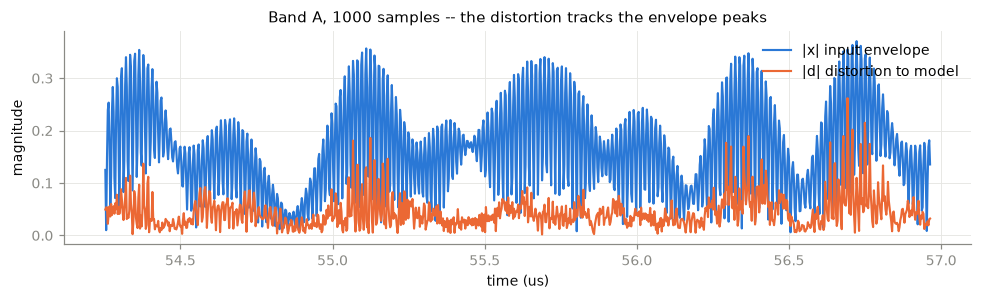

In [5]:
band = geo.bands["A"]
sl = slice(20000, 21000)
t_us = np.arange(sl.start, sl.stop) / geo.fs_hz * 1e6

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(t_us, np.abs(band.x[sl]), color=BLUE, label="|x| input envelope")
ax.plot(t_us, np.abs(band.d[sl]), color=ORANGE, label="|d| distortion to model")
ax.set_xlabel("time (us)"); ax.set_ylabel("magnitude")
ax.set_title("Band A, 1000 samples -- the distortion tracks the envelope peaks")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()

The distortion rides on the envelope: it grows where the input is large. That is the amplifier compressing on peaks, and it is the whole reason a memory *polynomial in the envelope* works at all.

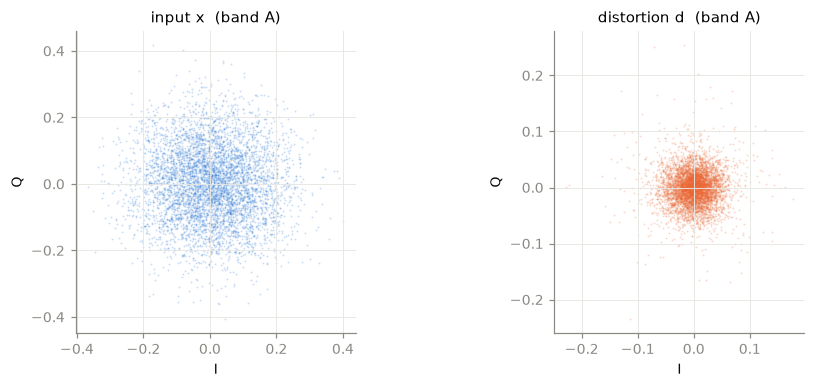

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
step = 40
axes[0].scatter(band.x[::step].real, band.x[::step].imag, s=1.5, color=BLUE, alpha=0.25, linewidths=0)
axes[0].set_title("input x  (band A)"); axes[0].set_aspect("equal")
axes[1].scatter(band.d[::step].real, band.d[::step].imag, s=1.5, color=ORANGE, alpha=0.25, linewidths=0)
axes[1].set_title("distortion d  (band A)"); axes[1].set_aspect("equal")
for a in axes:
    a.set_xlabel("I"); a.set_ylabel("Q")
plt.tight_layout(); plt.show()

Both clouds are **circularly symmetric** — no preferred phase. That is the symmetry the Clifford model in section 11 is built around: rotating the constellation must rotate the output the same way, because the amplifier has no phase reference of its own.

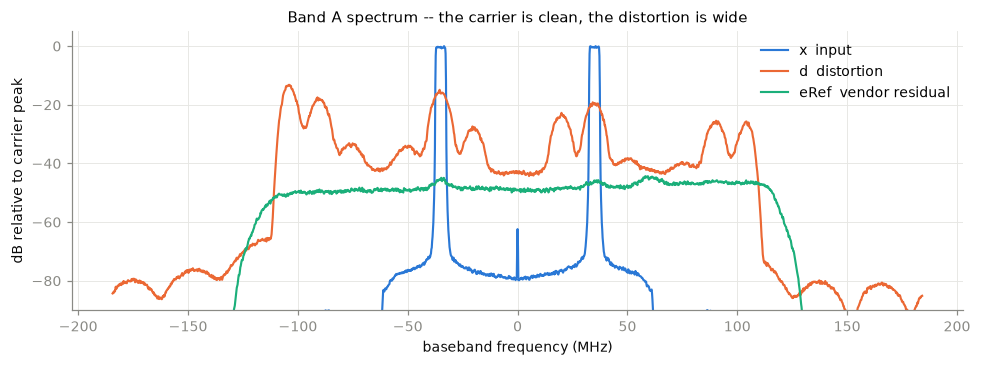

In [7]:
from rfpa.metrics import welch_psd

fig, ax = plt.subplots(figsize=(9, 3.4))
for name, sig, colour in [("x  input", band.x, BLUE),
                          ("d  distortion", band.d, ORANGE),
                          ("eRef  vendor residual", band.e_ref, AQUA)]:
    f, psd = welch_psd(sig, 2048, geo.fs_hz)
    ax.plot(f / 1e6, psd - psd.max() if name.startswith("x") else psd - welch_psd(band.x, 2048, geo.fs_hz)[1].max(),
            color=colour, label=name)
ax.set_xlabel("baseband frequency (MHz)"); ax.set_ylabel("dB relative to carrier peak")
ax.set_title("Band A spectrum -- the carrier is clean, the distortion is wide")
ax.legend(loc="upper right"); ax.set_ylim(-90, 5)
plt.tight_layout(); plt.show()

Three things to read off this plot:

- the **carrier** occupies about ±37 MHz and falls off sharply;
- the **distortion** is far wider — that spread outside the carrier is spectral regrowth, the thing spectral masks regulate;
- the **vendor residual** is ~30 dB down on the distortion, which is the bar.

<a id="4"></a>
## 4. The NMSE convention (read this one)

Every number in this project is

```
NMSE_dB = 10*log10( sum|e|^2 / sum|xRef|^2 )
```

with `e` the residual and `xRef` the **input carrier**. It is **negative, and lower is better**.

In [8]:
from rfpa.matlab import nmse_db

print("nmse_db(x, x)        =", f"{nmse_db(band.x, band.x):7.2f} dB   <- residual equals the carrier")
print("nmse_db(x, x/10)     =", f"{nmse_db(band.x, band.x/10):7.2f} dB   <- 10x smaller residual")
print("nmse_db(x, x/100)    =", f"{nmse_db(band.x, band.x/100):7.2f} dB   <- 100x smaller, better still")
print()
print("predicting zero      =", f"{nmse_db(band.x, band.d):7.3f} dB")
print("vendor's model       =", f"{nmse_db(band.x, band.e_ref):7.3f} dB   <- 22.6 dB better")

nmse_db(x, x)        =    0.00 dB   <- residual equals the carrier
nmse_db(x, x/10)     =  -20.00 dB   <- 10x smaller residual
nmse_db(x, x/100)    =  -40.00 dB   <- 100x smaller, better still

predicting zero      = -10.892 dB
vendor's model       = -33.451 dB   <- 22.6 dB better


Most of the published literature normalises by the **desired signal** instead of the carrier. The two differ by exactly the no-model floor, so converting is a subtraction:

In [9]:
from rfpa.metrics import summarise

# Treat the vendor's residual as a model: its implied output is y = d - eRef.
s = summarise(band.x, band.d, band.d - band.e_ref, band.e_ref)
for k, v in s.items():
    print(f"  {k:20s} {v:8.3f} dB")

print("\nThe two conventions, for that same model:")
print(f"  carrier-referred (here)   {s['nmse_model_db']:8.3f} dB")
print(f"  desired-referred (papers) {nmse_db(band.d, band.e_ref):8.3f} dB")
print(f"  ... which is just -improvement_db = {-s['improvement_db']:.3f} dB")

  nmse_model_db         -33.451 dB
  nmse_no_model_db      -10.892 dB
  nmse_reference_db     -33.451 dB
  improvement_db         22.559 dB

The two conventions, for that same model:
  carrier-referred (here)    -33.451 dB
  desired-referred (papers)  -22.559 dB
  ... which is just -improvement_db = -22.559 dB


<a id="5"></a>
## 5. Inside the reference model

The supplied MATLAB model is a **Chebyshev memory polynomial**:

```
y(k) = BL * sum_m sum_n  c_{m,n} * x_1(k - s_m) * prod_p T_{n_p}( |x_p(k - l_m - u_pm)| )
```

A delayed copy of the carrier, multiplied by a polynomial in the envelope magnitudes, band-limited. Let us look at each piece.

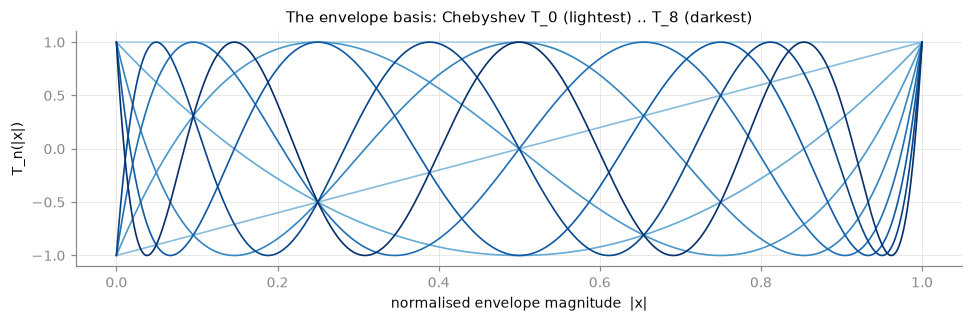

lookup table shape: (9, 32768) -- indexed by round(|x| * 0.99 * 2**15)


In [10]:
from rfpa.matlab import gen_spl_chebyshev

table = gen_spl_chebyshev(9)            # 9 basis functions over a 2^15-entry magnitude grid
mag = (np.arange(2**15) + 0.5) / 2**15

fig, ax = plt.subplots(figsize=(9, 3.0))
ramp = plt.cm.Blues(np.linspace(0.35, 1.0, 9))   # ordinal index -> sequential single hue
for k in range(9):
    ax.plot(mag, table[k], color=ramp[k], linewidth=1.1)
ax.set_xlabel("normalised envelope magnitude  |x|"); ax.set_ylabel("T_n(|x|)")
ax.set_title("The envelope basis: Chebyshev T_0 (lightest) .. T_8 (darkest)")
plt.tight_layout(); plt.show()

print("lookup table shape:", table.shape, "-- indexed by round(|x| * 0.99 * 2**15)")

In [11]:
from rfpa.features import PartModel

pm = PartModel.default(2)
print("part model, rows [s; l; u1; u2], one column per part:\n")
for name, row in zip(["s ", "l ", "u1", "u2"], pm.matrix):
    print(f"  {name} {row}")
print(f"\ndim={pm.dim}  parts={pm.n_parts}  max |delay|={pm.max_abs_delay}")
print(f"coefficients at Chebyshev order 8: {pm.n_parts} parts x 9 x 9 = {pm.n_parts*81}")

part model, rows [s; l; u1; u2], one column per part:

  s  [ 0  2 -1  1  2  0  8  3  0  1  1 10  0 -2  2]
  l  [ 1  2  0  1  1  0  0  1  1  2 -1  0  2  0  2]
  u1 [-1 -2 -1  0  1  1  4  2  0 -2  0  0  0 -2 -1]
  u2 [0 1 1 0 1 0 0 1 0 0 1 1 0 1 1]

dim=2  parts=15  max |delay|=10
coefficients at Chebyshev order 8: 15 parts x 9 x 9 = 1215


Each column is one *part*: a carrier delay `s`, a common envelope delay `l`, and a per-band extra delay `u_p`. The 15 columns were hand-tuned by the original author. **This delay structure matters more than the polynomial order** — section 9 and the README show order 2 gets within 1.9 dB of order 8.

<a id="6"></a>
## 6. Fitting it

The model is linear in its coefficients, so identification is a least-squares solve — no gradient descent needed. This takes ~30 s.

In [12]:
from rfpa.models import MemoryPolynomialPA
from rfpa.data import BL_DEFAULT, Split

x, scales = geo.normalised_stack("AB")   # rows scaled to unit peak -- required by the LUT indexing
split = Split.contiguous(band.n)         # 80/20 contiguous, 512-sample guard

model = MemoryPolynomialPA(pm, [8, 8], BL_DEFAULT, quantise=True)
t0 = time.time()
info = model.fit_least_squares(x, band.d, indices=split.train)
print(f"fitted {info['n_coef']} coefficients in {time.time()-t0:.1f} s")

with torch.no_grad():
    y = model(torch.as_tensor(x)).numpy()
resid = band.d - y

print(f"\n  no model        {nmse_db(band.x, band.d):8.3f} dB")
print(f"  train           {nmse_db(band.x[split.train], resid[split.train]):8.3f} dB")
print(f"  validation      {nmse_db(band.x[split.val], resid[split.val]):8.3f} dB")
print(f"  vendor model    {nmse_db(band.x, band.e_ref):8.3f} dB")

fitted 1215 coefficients in 28.4 s



  no model         -10.892 dB
  train            -24.123 dB
  validation       -24.139 dB
  vendor model     -33.451 dB


Train and validation agree to about 0.02 dB, so 1215 coefficients over 221000 samples is **not overfitting**.

Note `normalised_stack` — the Chebyshev basis is indexed by `round(|x| * 0.99 * 2^15)` and runs off its lookup table unless each row is unit-peak. But the NMSE reference stays the *unnormalised* `band.x`; mixing those up shifts every figure by 6.6 dB.

In [13]:
# The model is a torch Module, so the forward pass is differentiable and fast.
xt = torch.as_tensor(x)
t0 = time.time()
with torch.no_grad():
    _ = model(xt)
print(f"forward pass over all {band.n} samples: {time.time()-t0:.2f} s")
print(f"coefficient tensor: {tuple(model.coef.shape)}  (parts, T_n order band A, T_n order band B)")
print(f"differentiable w.r.t. {sum(p.numel() for p in model.parameters())} complex parameters")

forward pass over all 221000 samples: 0.59 s
coefficient tensor: (15, 9, 9)  (parts, T_n order band A, T_n order band B)
differentiable w.r.t. 1215 complex parameters


<a id="7"></a>
## 7. Where the residual goes

NMSE is a total-power number. It says nothing about *where* the leftover error sits in frequency — and for a PA that is usually the question that matters.

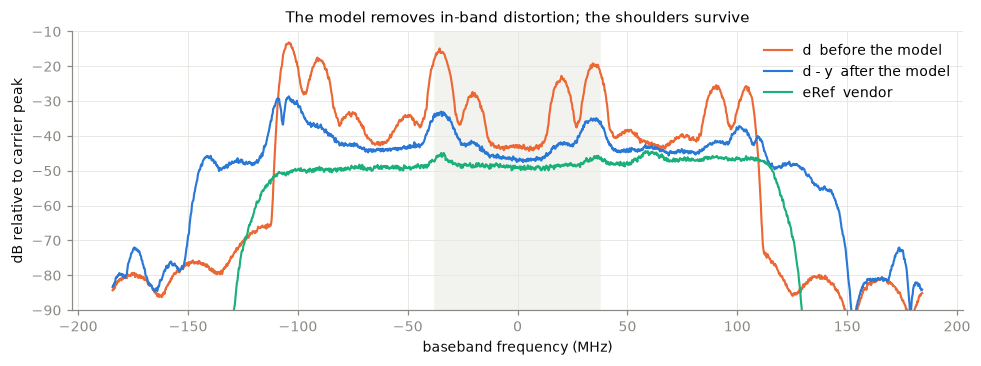

In [14]:
fig, ax = plt.subplots(figsize=(9, 3.4))
ref_peak = welch_psd(band.x, 2048, geo.fs_hz)[1].max()
for name, sig, colour in [("d  before the model", band.d, ORANGE),
                          ("d - y  after the model", resid, BLUE),
                          ("eRef  vendor", band.e_ref, AQUA)]:
    f, psd = welch_psd(sig, 2048, geo.fs_hz)
    ax.plot(f / 1e6, psd - ref_peak, color=colour, label=name)
ax.axvspan(-37.5, 37.5, color="#f2f2ef", zorder=0)
ax.set_xlabel("baseband frequency (MHz)"); ax.set_ylabel("dB relative to carrier peak")
ax.set_title("The model removes in-band distortion; the shoulders survive")
ax.legend(loc="upper right"); ax.set_ylim(-90, -10)
plt.tight_layout(); plt.show()

In [15]:
from rfpa.metrics import acpr_db

print("ACPR (adjacent-band power / in-band power; lower is cleaner)\n")
for name, sig in [("input xA", band.x), ("distortion dA", band.d),
                  ("residual d-y", resid), ("vendor eRef", band.e_ref)]:
    print(f"  {name:16s} {acpr_db(sig, occupied=75e6, offset=90e6, nfft=2048, fs=geo.fs_hz):7.2f} dB")

ACPR (adjacent-band power / in-band power; lower is cleaner)

  input xA          -74.91 dB
  distortion dA       1.93 dB
  residual d-y        4.17 dB
  vendor eRef         2.63 dB


The shaded band is the carrier. The model takes 13 dB out of the total error power, but almost all of it comes from **inside** the carrier — the out-of-band shoulders barely move, and the residual's ACPR is actually *worse* than the distortion it started from.

That is a real limitation of optimising NMSE alone, and it is invisible in the NMSE number. If the end goal is DPD, a spectrally weighted loss is probably the more useful objective.

<a id="8"></a>
## 8. The learned gain

The model can be read as a complex gain multiplying the carrier: `y ≈ g(k) * x(k)`. Plotting `g` against the envelope recovers the classic **AM/AM** and **AM/PM** curves.

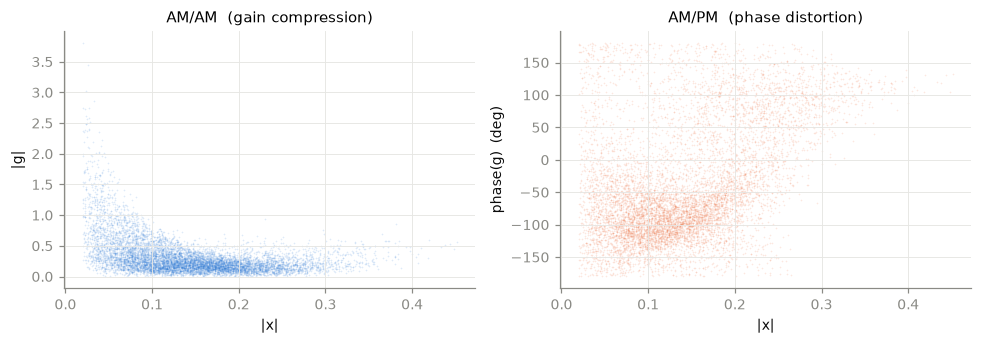

In [16]:
mask = np.abs(band.x) > 0.02          # gain is meaningless where the carrier is ~0
g = y[mask] / band.x[mask]
env = np.abs(band.x[mask])
step = 25

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].scatter(env[::step], np.abs(g[::step]), s=1.2, color=BLUE, alpha=0.15, linewidths=0)
axes[0].set_xlabel("|x|"); axes[0].set_ylabel("|g|"); axes[0].set_title("AM/AM  (gain compression)")
axes[1].scatter(env[::step], np.angle(g[::step], deg=True), s=1.2, color=ORANGE, alpha=0.15, linewidths=0)
axes[1].set_xlabel("|x|"); axes[1].set_ylabel("phase(g)  (deg)"); axes[1].set_title("AM/PM  (phase distortion)")
plt.tight_layout(); plt.show()

The vertical spread at each `|x|` is **memory** — the gain depends not only on the present envelope but on its recent history and on band B. A memoryless model would give two thin curves.

This quantity — the complex gain, invariant to input phase — is exactly what section 11's Clifford model produces as a rotor invariant.

<a id="9"></a>
## 9. Why band B matters and band C does not

The carriers sit at 1.84, 2.14 and 2.66 GHz. Cross-modulation falls off with separation, and it shows up starkly in the fits. Chebyshev order 4 here to keep it quick.

In [17]:
results = {}
for bands in ["A", "AB", "AC"]:
    xb, _ = geo.normalised_stack(bands)
    nb = [4] * len(bands)
    m = MemoryPolynomialPA(PartModel.default(len(bands)), nb, BL_DEFAULT, quantise=True)
    m.fit_least_squares(xb, band.d, indices=split.train)
    with torch.no_grad():
        yb = m(torch.as_tensor(xb)).numpy()
    results[bands] = nmse_db(band.x[split.val], (band.d - yb)[split.val])
    print(f"  band A modelled from {bands:3s}  ->  {results[bands]:7.3f} dB val")

  band A modelled from A    ->  -14.518 dB val


  band A modelled from AB   ->  -23.818 dB val


  band A modelled from AC   ->  -14.570 dB val


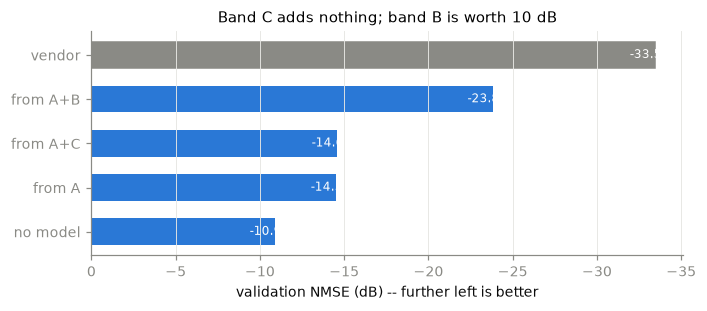

In [18]:
fig, ax = plt.subplots(figsize=(6.5, 2.9))
labels = ["no model", "from A", "from A+C", "from A+B", "vendor"]
values = [nmse_db(band.x, band.d), results["A"], results["AC"], results["AB"],
          nmse_db(band.x, band.e_ref)]
bars = ax.barh(labels, values, color=BLUE, height=0.6)
bars[-1].set_color(MUTED)
for lab, v in zip(labels, values):
    ax.text(v - 0.4, lab, f"{v:.1f}", va="center", ha="right", color="white", fontsize=8)
ax.set_xlabel("validation NMSE (dB) -- further left is better")
ax.set_title("Band C adds nothing; band B is worth 10 dB")
ax.invert_xaxis(); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

Band B is 298 MHz from band A and worth ~10 dB. Band C is 813 MHz away and worth ~0.1 dB. So the useful model here is **two-dimensional**, not three — the third carrier buys 0.33 dB out of sample at 2.8x the coefficients.

<a id="10"></a>
## 10. The geometric algebra

Now the research side. The motivation is the circular symmetry we saw in section 3: rotating the input constellation must rotate the output identically.

Memory polynomials get this by construction — every term is `x * f(|x|)`, one unpaired carrier times a function of magnitudes — which is *also* why the envelope nonlinearity can never see a phase.

In `Cl(2,0)` the I/Q plane is a real vector space with four blades: `1`, `e1`, `e2`, `e12`.

In [19]:
from rfpa.ga import CliffordAlgebra

alg = CliffordAlgebra(2, 0)
e = torch.eye(4, dtype=torch.float64)
names = ["1", "e1", "e2", "e12"]
print("Cayley table (row * column):\n")
print("        " + "".join(f"{n:>7s}" for n in names))
for i, ni in enumerate(names):
    row = []
    for j in range(4):
        p = alg.geometric_product(e[i], e[j]).numpy()
        k = int(np.argmax(np.abs(p)))
        row.append(("-" if p[k] < 0 else "") + names[k])
    print(f"  {ni:>5s} " + "".join(f"{r:>7s}" for r in row))
print("\ngrades:", alg.grades.tolist(), " -- blade 0 is scalar, 1 and 2 are vectors, 3 is the bivector")

Cayley table (row * column):

              1     e1     e2    e12
      1       1     e1     e2    e12
     e1      e1      1    e12     e2
     e2      e2   -e12      1    -e1
    e12     e12    -e2     e1     -1

grades: [0, 1, 1, 2]  -- blade 0 is scalar, 1 and 2 are vectors, 3 is the bivector


**Fact 1: a phase rotation is a rotor sandwich.** Embed `z = I + jQ` as the vector `I*e1 + Q*e2`. Then conjugating by `R = exp(-phi/2 * e12)` rotates it:

In [20]:
z = torch.complex(torch.randn(4, dtype=torch.float64), torch.randn(4, dtype=torch.float64))
phi = torch.tensor(0.7, dtype=torch.float64)

rotated = alg.sandwich(alg.rotor(phi.expand(4)), alg.embed_complex(z))
print("R v R~   ->", np.round(alg.extract_complex(rotated).numpy(), 6))
print("z e^{j phi} ->", np.round((z * torch.exp(1j * phi)).numpy(), 6))
print("\nmax difference:", np.abs(alg.extract_complex(rotated).numpy() - (z*torch.exp(1j*phi)).numpy()).max())

R v R~   -> [-0.61256 +0.806732j  2.32914 +0.014461j -1.934459+0.46439j
  1.595477+0.084809j]
z e^{j phi} -> [-0.61256 +0.806732j  2.32914 +0.014461j -1.934459+0.46439j
  1.595477+0.084809j]

max difference: 4.577566798522237e-16


**Fact 2: the even part is invariant.** The even subalgebra (blades `1` and `e12`) commutes with every rotor, so `R a R~ = a R R~ = a`. And since `e12^2 = -1`, that even part *is* a copy of the complex numbers:

In [21]:
a = torch.randn(6, 4, dtype=torch.float64)
out = alg.sandwich(alg.rotor(torch.rand(6, dtype=torch.float64) * 6.0), a)

print("blade         max |change| under a random rotation")
for i, n in enumerate(names):
    tag = "  <- invariant (even)" if i in (0, 3) else ""
    print(f"  {n:>5s}        {(out[:, i] - a[:, i]).abs().max().item():.2e}{tag}")

blade         max |change| under a random rotation
      1        2.22e-16  <- invariant (even)
     e1        1.79e+00
     e2        3.65e+00
    e12        1.11e-16  <- invariant (even)


Put together: **the even part of a multivector is a complex number that does not move when you rotate the constellation** — which is precisely what a PA complex gain is. The AM/AM + AM/PM characteristic of section 8 falls out as a symmetry property instead of being imposed by restricting the basis to `|x|`.

<a id="11"></a>
## 11. The Clifford model

`CliffordPAModel` keeps the reference model's outer form, `y = BL * sum_i g_i(k) * x_1(k - s_i)`, and computes the gains `g_i` with an equivariant network over the delayed envelopes of all carriers.

In [22]:
from rfpa.clifford_model import CliffordPAModel

torch.manual_seed(0)
cmodel = CliffordPAModel(n_bands=2, env_taps=range(-2, 9), linear_taps=(0, 1, 2),
                         channels=16, n_blocks=2, bl=BL_DEFAULT)
print(cmodel)
print(f"\nparameters: {cmodel.n_parameters}   (the reference uses 1215 complex = 2430 real)")

CliffordPAModel(
  (embed): MVLinear()
  (blocks): ModuleList(
    (0-1): 2 x MVBlock(
      (gp): MVGeometricProduct(
        (left): MVLinear()
        (right): MVLinear()
        (out): MVLinear()
      )
      (gate): MVInvariantGate(
        (mlp): Sequential(
          (0): Linear(in_features=48, out_features=64, bias=True)
          (1): SiLU()
          (2): Linear(in_features=64, out_features=64, bias=True)
          (3): SiLU()
          (4): Linear(in_features=64, out_features=48, bias=True)
        )
      )
    )
  )
  (readout): MVLinear()
)

parameters: 26691   (the reference uses 1215 complex = 2430 real)


In [23]:
# The readout is zero-initialised, so an untrained model outputs exactly zero.
xw = torch.as_tensor(x[:, :8192], dtype=torch.complex64)
with torch.no_grad():
    print("untrained output max |y|:", cmodel(xw).abs().max().item())

# Perturb it so the equivariance check is not trivially satisfied.
for p in cmodel.readout.parameters():
    with torch.no_grad():
        p.add_(torch.randn_like(p) * 0.3)

phi = torch.tensor(1.1)
with torch.no_grad():
    y0 = cmodel(xw)
    y1 = cmodel(xw * torch.exp(1j * phi))
    g0 = cmodel.gains(xw)
    g1 = cmodel.gains(xw * torch.exp(1j * phi))

print(f"\nequivariance  |y(x e^{{j phi}}) - y(x) e^{{j phi}}| / max|y|  =  "
      f"{((y1 - y0*torch.exp(1j*phi)).abs().max() / y0.abs().max()).item():.2e}")
print(f"gain invariance  |g(x e^{{j phi}}) - g(x)| / max|g|          =  "
      f"{((g1 - g0).abs().max() / g0.abs().max()).item():.2e}")

untrained output max |y|: 0.0



equivariance  |y(x e^{j phi}) - y(x) e^{j phi}| / max|y|  =  3.38e-07
gain invariance  |g(x e^{j phi}) - g(x)| / max|g|          =  3.51e-07


Exact to float32 precision. The symmetry is structural, not learned — it holds at initialisation, during training and after.

A short training run, just to see the loop work. **This will not reach the baseline** — see below.

In [24]:
from rfpa.training import TrainConfig, train

torch.manual_seed(0)
cmodel = CliffordPAModel(n_bands=2, env_taps=range(-2, 9), linear_taps=(0, 1, 2),
                         channels=16, n_blocks=2, bl=BL_DEFAULT)
xt32 = torch.as_tensor(x, dtype=torch.complex64)
dt32 = torch.as_tensor(band.d, dtype=torch.complex64)

history = train(cmodel, xt32, dt32, band.x, split,
                TrainConfig(steps=300, window=8192, lr=5e-3, log_every=100))

  step   100  batch  -11.790 dB  train  -12.055 dB  val  -12.159 dB  (4s)


  step   200  batch  -11.908 dB  train  -12.120 dB  val  -12.208 dB  (9s)


  step   300  batch  -11.923 dB  train  -12.171 dB  val  -12.210 dB  (12s)


### Where this stands

| model | parameters | validation NMSE |
|---|---|---|
| no model | — | -10.892 dB |
| reference memory polynomial | 1215 complex | **-24.139 dB** |
| Clifford model (600 steps) | 26691 real | -12.221 dB |

The Clifford model is **not yet competitive**, and the gap is not a training-length artefact.
The diagnostic: the output is exactly *linear* in the readout parameters, so the best possible
readout on a given trunk can be solved in closed form. A **random** trunk supports -11.5 dB;
training reaches -12.2 dB. The trunk is producing almost nothing the readout can use — a
representation problem, not an optimisation or capacity one. For comparison, the reference
reaches -18.8 dB with just 60 coefficients.

<a id="12"></a>
## 12. Next steps

Ranked, from `docs/clifford-model.md`:

1. **Delay coverage.** The reference spends 15 hand-tuned delay triples with `s` in -2..10 and independent `u_p` per band; the Clifford model uses a regular tap grid and 3 linear taps. Section 5 and the order sweep both say the delay structure carries most of the performance, so feeding the reference part model's taps to the Clifford model is the first thing to try.
2. **Envelope dynamic range.** The invariants entering the gate are *squared* norms of unit-peak envelopes, so they concentrate near zero and the gate MLP sees a compressed input. Try `|x|` instead of `|x|^2`, or standardise the invariants.
3. **Depth vs. order.** Each geometric-product block roughly doubles polynomial degree — two blocks reach degree 4 against the reference's degree 8 per dimension.
4. **Warm start from the reference.** The reference is the special case where the gain is a separable magnitude polynomial. Initialising the Clifford model to reproduce a fitted memory polynomial would separate "can it represent the baseline" from "can it find it".

Also worth considering, from section 7: a **spectrally weighted loss**, since plain NMSE leaves the out-of-band shoulders untouched.

Further reading: [`docs/metrics.md`](../docs/metrics.md) · [`docs/reference-model.md`](../docs/reference-model.md) · [`docs/clifford-model.md`](../docs/clifford-model.md) · [`docs/data.md`](../docs/data.md)